In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm, norm

train = pd.read_csv("../../data/optiver_volatility/train.csv")
print(train.shape)
print(train)

n_stocks = train["stock_id"].nunique()
n_time_ids = train["time_id"].nunique()
stocks_per_time = train.groupby("time_id")["stock_id"].nunique()
times_per_stock = train.groupby("stock_id")["time_id"].nunique()

print(f"train rows: {len(train):,}")
print(f"stocks: {n_stocks:,} | stock_id range: {train['stock_id'].min()} to {train['stock_id'].max()}")
print(f"time_ids: {n_time_ids:,} | time_id range: {train['time_id'].min()} to {train['time_id'].max()}")
print(f"missing stock-time rows from full grid: {n_stocks * n_time_ids - len(train):,}")

print("\nStocks per time_id:")
display(stocks_per_time.value_counts().sort_index().rename_axis("n_stocks").reset_index(name="n_time_ids"))

print("\nTime_ids per stock:")
display(times_per_stock.value_counts().sort_index().rename_axis("n_time_ids").reset_index(name="n_stocks"))

(428932, 3)
        stock_id  time_id    target
0              0        5  0.004136
1              0       11  0.001445
2              0       16  0.002168
3              0       31  0.002195
4              0       62  0.001747
...          ...      ...       ...
428927       126    32751  0.003461
428928       126    32753  0.003113
428929       126    32758  0.004070
428930       126    32763  0.003357
428931       126    32767  0.002090

[428932 rows x 3 columns]
train rows: 428,932
stocks: 112 | stock_id range: 0 to 126
time_ids: 3,830 | time_id range: 5 to 32767
missing stock-time rows from full grid: 28

Stocks per time_id:


,n_stocks,n_time_ids
0,111,28
1,112,3802



Time_ids per stock:


,n_time_ids,n_stocks
0,3815,1
1,3820,1
2,3829,3
3,3830,107


In [2]:
time_ids_sorted = np.array(sorted(train["time_id"].unique()))
split_idx = len(time_ids_sorted) // 2

train_time_ids = time_ids_sorted[:split_idx]
test_time_ids = time_ids_sorted[split_idx:]

train_split = train[train["time_id"].isin(train_time_ids)].copy()
test_split = train[train["time_id"].isin(test_time_ids)].copy()

print(f"train_split: {train_split.shape[0]:,} rows, {train_split['time_id'].nunique():,} time_ids")
print(f"test_split:  {test_split.shape[0]:,} rows, {test_split['time_id'].nunique():,} time_ids")
print(f"train time_id range: {train_time_ids.min()} to {train_time_ids.max()}")
print(f"test time_id range:  {test_time_ids.min()} to {test_time_ids.max()}")


train_split: 214,465 rows, 1,915 time_ids
test_split:  214,467 rows, 1,915 time_ids
train time_id range: 5 to 15852
test time_id range:  15853 to 32767


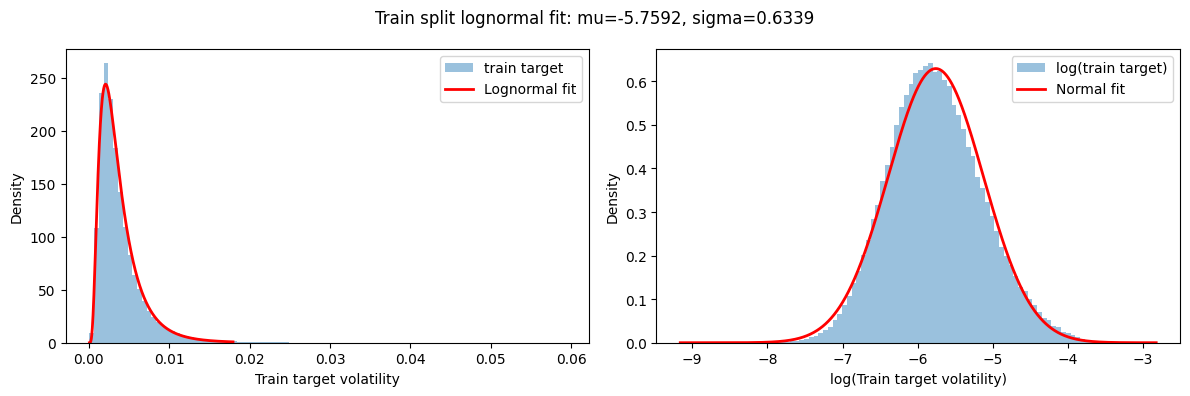

In [4]:
target = train_split["target"].dropna()
shape, loc, scale = lognorm.fit(target, floc=0)
mu = np.log(scale)
sigma = shape

x = np.linspace(target.min(), target.quantile(0.995), 1000)
log_target = np.log(target)
log_x = np.linspace(log_target.min(), log_target.max(), 1000)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(target, bins=100, density=True, alpha=0.45, label="train target")
axes[0].plot(x, lognorm.pdf(x, shape, loc=loc, scale=scale), color="red", linewidth=2, label="Lognormal fit")
axes[0].set_xlabel("Train target volatility")
axes[0].set_ylabel("Density")
axes[0].legend()

axes[1].hist(log_target, bins=100, density=True, alpha=0.45, label="log(train target)")
axes[1].plot(log_x, norm.pdf(log_x, mu, sigma), color="red", linewidth=2, label="Normal fit")
axes[1].set_xlabel("log(Train target volatility)")
axes[1].set_ylabel("Density")
axes[1].legend()


fig.suptitle(f"Train split lognormal fit: mu={mu:.4f}, sigma={sigma:.4f}")
plt.tight_layout()
plt.show()


In [5]:
stock_id = 0
time_id = train_time_ids[0]

book = pd.read_parquet(
    f"../../data/optiver_volatility/book_train.parquet/stock_id={stock_id}"
)

trade = pd.read_parquet(
    f"../../data/optiver_volatility/trade_train.parquet/stock_id={stock_id}"
)

target = train.loc[
    (train["stock_id"] == stock_id) &
    (train["time_id"] == time_id),
    "target"
].iloc[0]



print(f"stock_id = {stock_id}")
print(f"time_id  = {time_id}")
print(f"target   = {target}")



print("\nBOOK DATA")
print(book.shape)

display(book[book["time_id"] == time_id])

print("\nTRADE DATA")
display(trade[trade["time_id"] == time_id])



stock_id = 0
time_id  = 5
target   = 0.004135767

BOOK DATA
(917553, 10)


,time_id,seconds_in_bucket,bid_price1,ask_price1,bid_price2,ask_price2,bid_size1,ask_size1,bid_size2,ask_size2
0,5,0,1.001422,1.002301,1.001370,1.002353,3,226,2,100
1,5,1,1.001422,1.002301,1.001370,1.002353,3,100,2,100
2,5,5,1.001422,1.002301,1.001370,1.002405,3,100,2,100
3,5,6,1.001422,1.002301,1.001370,1.002405,3,126,2,100
4,5,7,1.001422,1.002301,1.001370,1.002405,3,126,2,100
...,...,...,...,...,...,...,...,...,...,...
297,5,585,1.003129,1.003749,1.003025,1.003801,100,3,26,3
298,5,586,1.003129,1.003749,1.002612,1.003801,100,3,2,3
299,5,587,1.003129,1.003749,1.003025,1.003801,100,3,26,3
300,5,588,1.003129,1.003749,1.002612,1.003801,100,3,2,3



TRADE DATA


,time_id,seconds_in_bucket,price,size,order_count
0,5,21,1.002301,326,12
1,5,46,1.002778,128,4
2,5,50,1.002818,55,1
3,5,57,1.003155,121,5
4,5,68,1.003646,4,1
5,5,78,1.003762,134,5
6,5,122,1.004207,102,3
7,5,127,1.004577,1,1
8,5,144,1.004370,6,1
9,5,147,1.003964,233,4


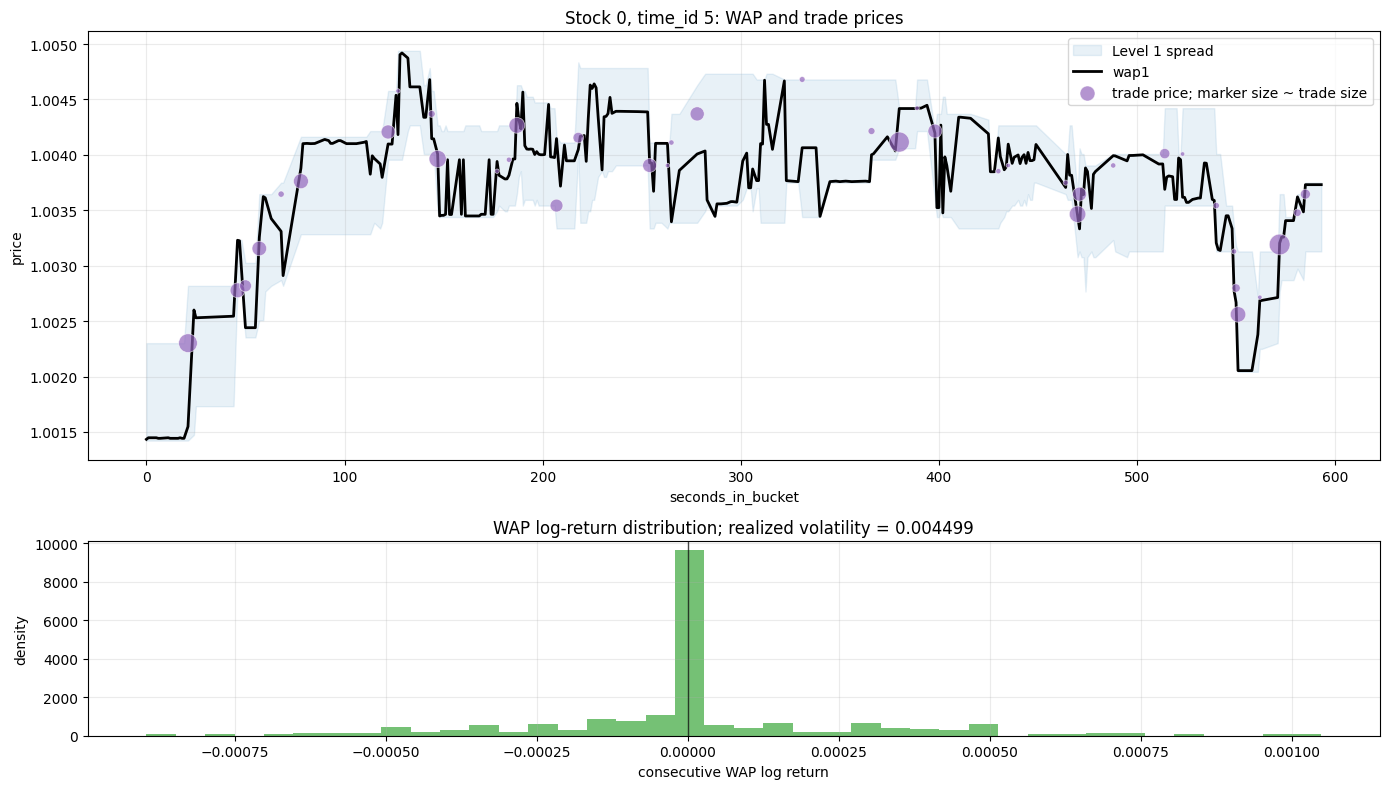

In [ ]:
book_slice = book[book["time_id"] == time_id].copy()
trade_slice = trade[trade["time_id"] == time_id].copy()

book_slice["wap1"] = (
    book_slice["bid_price1"] * book_slice["ask_size1"]
    + book_slice["ask_price1"] * book_slice["bid_size1"]
) / (book_slice["bid_size1"] + book_slice["ask_size1"])
book_slice["wap1_log_return"] = np.log(book_slice["wap1"]).diff()
wap_log_returns = book_slice["wap1_log_return"].dropna()
realized_volatility = np.sqrt(np.sum(wap_log_returns ** 2))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [2.2, 1]})
price_ax, return_ax = axes

price_ax.fill_between(
     book_slice["seconds_in_bucket"],
     book_slice["bid_price1"],
     book_slice["ask_price1"],
     color="tab:blue",
     alpha=0.10,
     label="Level 1 spread",
 )
# price_ax.plot(book_slice["seconds_in_bucket"], book_slice["bid_price1"], color="tab:blue", linewidth=1.4, label="bid_price1")
# price_ax.plot(book_slice["seconds_in_bucket"], book_slice["ask_price1"], color="tab:red", linewidth=1.4, label="ask_price1")
price_ax.plot(book_slice["seconds_in_bucket"], book_slice["wap1"], color="black", linewidth=2.0, label="wap1")

if not trade_slice.empty:
    trade_sizes = np.sqrt(trade_slice["size"].clip(lower=1)) * 10
    price_ax.scatter(
        trade_slice["seconds_in_bucket"],
        trade_slice["price"],
        s=trade_sizes,
        color="tab:purple",
        alpha=0.70,
        edgecolors="white",
        linewidths=0.5,
        label="trade price; marker size ~ trade size",
        zorder=5,
    )

price_ax.set_title(f"Stock {stock_id}, time_id {time_id}: WAP and trade prices")
price_ax.set_xlabel("seconds_in_bucket")
price_ax.set_ylabel("price")
price_ax.grid(True, alpha=0.25)
price_ax.legend(loc="best")

return_ax.hist(wap_log_returns, bins=40, density=True, alpha=0.65, color="tab:green")
return_ax.axvline(0, color="black", linewidth=1.0, alpha=0.7)
return_ax.set_title(f"WAP log-return distribution; realized volatility = {realized_volatility:.6f}")
return_ax.set_xlabel("consecutive WAP log return")
return_ax.set_ylabel("density")
return_ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()



,split,rows,r2,rmspe
0,train_split,214465,0.622455,0.338185
1,test_split,214467,0.634029,0.344495


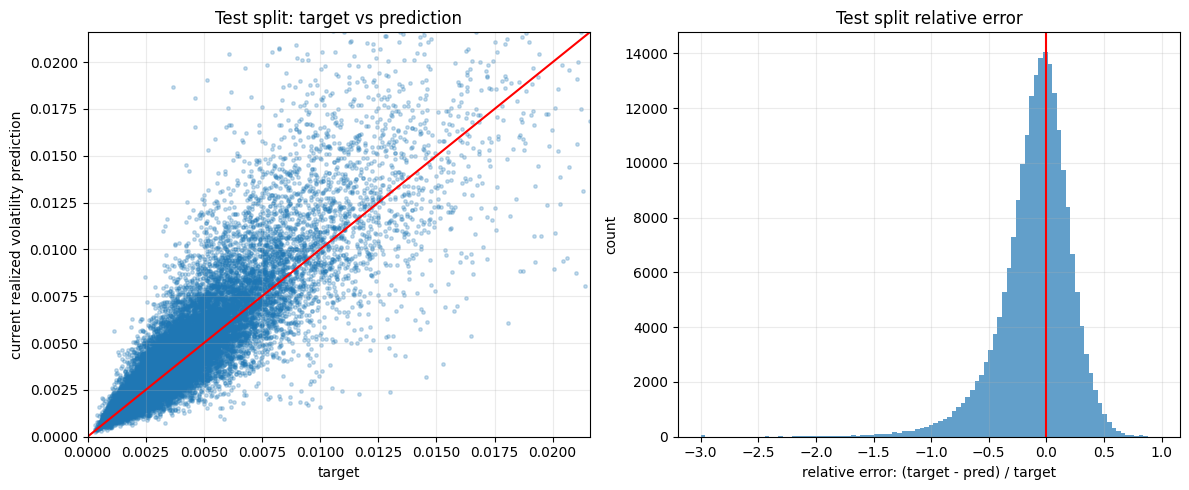

In [7]:
from pathlib import Path
from sklearn.metrics import r2_score

DATA_DIR = Path("../../data/optiver_volatility")

def rmspe(y_true, y_pred):
    return np.sqrt(np.mean(np.square((y_true - y_pred) / y_true)))

def realized_volatility(series_log_return):
    return np.sqrt(np.sum(series_log_return ** 2))

def realized_volatility_per_stock(stock_id):
    df_book = pd.read_parquet(DATA_DIR / "book_train.parquet" / f"stock_id={stock_id}")
    df_book["wap"] = (
        df_book["bid_price1"] * df_book["ask_size1"]
        + df_book["ask_price1"] * df_book["bid_size1"]
    ) / (df_book["bid_size1"] + df_book["ask_size1"])
    df_book["log_return"] = df_book.groupby("time_id")["wap"].transform(lambda x: np.log(x).diff())
    df_book = df_book.dropna(subset=["log_return"])

    df_rv = df_book.groupby("time_id")["log_return"].agg(realized_volatility).reset_index()
    df_rv = df_rv.rename(columns={"log_return": "pred"})
    df_rv["stock_id"] = stock_id
    return df_rv[["stock_id", "time_id", "pred"]]

df_current_rv = pd.concat(
    [realized_volatility_per_stock(stock_id) for stock_id in sorted(train["stock_id"].unique())],
    ignore_index=True,
)

train_eval = train_split.merge(df_current_rv, on=["stock_id", "time_id"], how="left").dropna(subset=["pred"])
test_eval = test_split.merge(df_current_rv, on=["stock_id", "time_id"], how="left").dropna(subset=["pred"])

scores = pd.DataFrame(
    [
        {
            "split": "train_split",
            "rows": len(train_eval),
            "r2": r2_score(train_eval["target"], train_eval["pred"]),
            "rmspe": rmspe(train_eval["target"], train_eval["pred"]),
        },
        {
            "split": "test_split",
            "rows": len(test_eval),
            "r2": r2_score(test_eval["target"], test_eval["pred"]),
            "rmspe": rmspe(test_eval["target"], test_eval["pred"]),
        },
    ]
)
display(scores)

plot_df = test_eval.sample(min(len(test_eval), 30000), random_state=42)
rel_error = (test_eval["target"] - test_eval["pred"]) / test_eval["target"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(plot_df["target"], plot_df["pred"], s=6, alpha=0.25)
limit = max(plot_df["target"].quantile(0.995), plot_df["pred"].quantile(0.995))
axes[0].plot([0, limit], [0, limit], color="red", linewidth=1.5)
axes[0].set_xlim(0, limit)
axes[0].set_ylim(0, limit)
axes[0].set_xlabel("target")
axes[0].set_ylabel("current realized volatility prediction")
axes[0].set_title("Test split: target vs prediction")
axes[0].grid(True, alpha=0.25)

axes[1].hist(rel_error.clip(-3, 3), bins=100, alpha=0.70)
axes[1].axvline(0, color="red", linewidth=1.5)
axes[1].set_xlabel("relative error: (target - pred) / target")
axes[1].set_ylabel("count")
axes[1].set_title("Test split relative error")
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


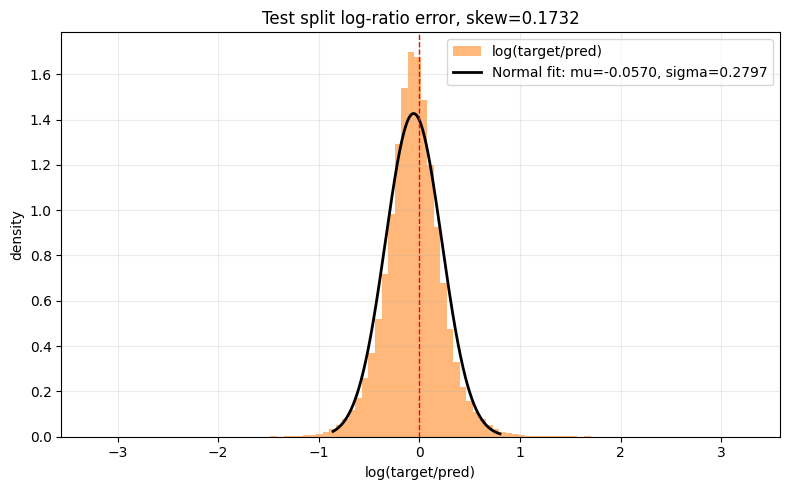

In [10]:
from scipy.stats import norm

log_ratio = np.log(test_eval["target"] / test_eval["pred"])
mu, sigma = norm.fit(log_ratio)
x = np.linspace(log_ratio.quantile(0.005), log_ratio.quantile(0.995), 1000)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(log_ratio, bins=100, density=True, alpha=0.55, color="tab:orange", label="log(target/pred)")
ax.plot(x, norm.pdf(x, mu, sigma), color="black", linewidth=2, label=f"Normal fit: mu={mu:.4f}, sigma={sigma:.4f}")
ax.axvline(0, color="red", linewidth=1.0, linestyle="--")
ax.set_xlabel("log(target/pred)")
ax.set_ylabel("density")
ax.set_title(f"Test split log-ratio error, skew={log_ratio.skew():.4f}")
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


In [17]:

# Single-stock, whole-window feature engineering (reuses book/trade already loaded for stock_id=0)
b = book.copy()
b["wap1"] = (b["bid_price1"] * b["ask_size1"] + b["ask_price1"] * b["bid_size1"]) / (b["bid_size1"] + b["ask_size1"])
b["wap2"] = (b["bid_price2"] * b["ask_size2"] + b["ask_price2"] * b["bid_size2"]) / (b["bid_size2"] + b["ask_size2"])
b["spread"] = (b["ask_price1"] - b["bid_price1"]) / b["wap1"]
b["imbalance"] = (b["bid_size1"] - b["ask_size1"]) / (b["bid_size1"] + b["ask_size1"])
b["ret1"] = b.groupby("time_id")["wap1"].transform(lambda s: np.log(s).diff())
b["ret2"] = b.groupby("time_id")["wap2"].transform(lambda s: np.log(s).diff())

book_feats = b.groupby("time_id").apply(lambda g: pd.Series({
    "rv_wap1": np.sqrt(np.sum(g["ret1"].dropna() ** 2)),
    "rv_wap2": np.sqrt(np.sum(g["ret2"].dropna() ** 2)),
    "spread_mean": g["spread"].mean(),
    "spread_std": g["spread"].std(),
    "imbalance_mean": g["imbalance"].mean(),
    "imbalance_std": g["imbalance"].std(),
    "n_updates": len(g),
    "wap_range": (g["wap1"].max() - g["wap1"].min()) / g["wap1"].mean(),
}), include_groups=False).reset_index()

t = trade.copy()
t["trade_ret"] = t.groupby("time_id")["price"].transform(lambda s: np.log(s).diff())
trade_feats = t.groupby("time_id").apply(lambda g: pd.Series({
    "trade_count": len(g),
    "trade_volume": g["size"].sum(),
    "avg_trade_size": g["size"].mean(),
    "rv_trade": np.sqrt(np.sum(g["trade_ret"].dropna() ** 2)),
}), include_groups=False).reset_index()

features = book_feats.merge(trade_feats, on="time_id", how="left")
features[["trade_count", "trade_volume", "avg_trade_size", "rv_trade"]] = features[
    ["trade_count", "trade_volume", "avg_trade_size", "rv_trade"]
].fillna(0)

print(f"stock_id = {stock_id} | feature rows: {len(features)}")
features.head()


stock_id = 0 | feature rows: 3830


,time_id,rv_wap1,rv_wap2,spread_mean,spread_std,imbalance_mean,imbalance_std,n_updates,wap_range,trade_count,trade_volume,avg_trade_size,rv_trade
0,5,0.004499,0.006999,0.000852,0.000211,-0.006357,0.708949,302.0,0.003473,40.0,3179.0,79.475000,0.002006
1,11,0.001204,0.002476,0.000394,0.000157,0.167165,0.702103,200.0,0.001134,30.0,1289.0,42.966667,0.000901
2,16,0.002369,0.004801,0.000725,0.000164,-0.105494,0.583874,188.0,0.003656,25.0,2161.0,86.440000,0.001961
3,31,0.002574,0.003637,0.000861,0.000280,0.056378,0.709451,120.0,0.002968,15.0,1962.0,130.800000,0.001561
4,62,0.001894,0.003257,0.000397,0.000130,0.088670,0.674933,176.0,0.000928,22.0,1791.0,81.409091,0.000871


In [18]:

# Single-stock, whole-window linear regression: target ~ engineered features
from sklearn.linear_model import LinearRegression

feature_cols = [
    "rv_wap1", "rv_wap2", "spread_mean", "spread_std",
    "imbalance_mean", "imbalance_std", "n_updates", "wap_range",
    "trade_count", "trade_volume", "rv_trade",
]

stock_target = train.loc[train["stock_id"] == stock_id, ["time_id", "target"]]
data = features.merge(stock_target, on="time_id", how="inner").dropna(subset=feature_cols)

train_data = data[data["time_id"].isin(train_time_ids)]
test_data = data[data["time_id"].isin(test_time_ids)]

lr = LinearRegression()
lr.fit(train_data[feature_cols], train_data["target"])

train_pred = lr.predict(train_data[feature_cols])
test_pred = lr.predict(test_data[feature_cols])

naive_test_rmspe = rmspe(test_data["target"], test_data["rv_wap1"])

print(f"stock_id = {stock_id} | train rows: {len(train_data)} | test rows: {len(test_data)}\n")
print("linear regression on engineered features:")
print(f"  train  r2={r2_score(train_data['target'], train_pred):.4f}  rmspe={rmspe(train_data['target'], train_pred):.4f}")
print(f"  test   r2={r2_score(test_data['target'], test_pred):.4f}  rmspe={rmspe(test_data['target'], test_pred):.4f}")
print(f"\nnaive rv_wap1 baseline (test): rmspe={naive_test_rmspe:.4f}")


stock_id = 0 | train rows: 1915 | test rows: 1915

linear regression on engineered features:
  train  r2=0.7601  rmspe=0.3150
  test   r2=0.7478  rmspe=0.3378

naive rv_wap1 baseline (test): rmspe=0.4062


In [38]:

# All-stocks, N-window feature engineering: split each 10-minute bucket into N equal sub-windows,
# computing the same feature set independently within each. N_WINDOWS=1 reproduces the whole-window version.
N_WINDOWS = 20
WINDOW_SECONDS = 600

BOOK_BASE_FEATURES = [
    "rv_wap1", "rv_wap2", "spread_mean", "spread_std",
    "imbalance_mean", "imbalance_std", "n_updates", "wap_range",
]
TRADE_BASE_FEATURES = ["trade_count", "trade_volume", "rv_trade"]

def compute_stock_features(stock_id, n=N_WINDOWS):
    b = pd.read_parquet(DATA_DIR / "book_train.parquet" / f"stock_id={stock_id}")
    b["wap1"] = (b["bid_price1"] * b["ask_size1"] + b["ask_price1"] * b["bid_size1"]) / (b["bid_size1"] + b["ask_size1"])
    b["wap2"] = (b["bid_price2"] * b["ask_size2"] + b["ask_price2"] * b["bid_size2"]) / (b["bid_size2"] + b["ask_size2"])
    b["spread"] = (b["ask_price1"] - b["bid_price1"]) / b["wap1"]
    b["imbalance"] = (b["bid_size1"] - b["ask_size1"]) / (b["bid_size1"] + b["ask_size1"])
    b["ret1"] = b.groupby("time_id")["wap1"].transform(lambda s: np.log(s).diff())
    b["ret2"] = b.groupby("time_id")["wap2"].transform(lambda s: np.log(s).diff())
    b["window"] = np.minimum((b["seconds_in_bucket"] * n // WINDOW_SECONDS).astype(int), n - 1)

    book_g = b.groupby(["time_id", "window"]).agg(
        rv_wap1=("ret1", lambda x: np.sqrt(np.nansum(x.to_numpy() ** 2))),
        rv_wap2=("ret2", lambda x: np.sqrt(np.nansum(x.to_numpy() ** 2))),
        spread_mean=("spread", "mean"),
        spread_std=("spread", "std"),
        imbalance_mean=("imbalance", "mean"),
        imbalance_std=("imbalance", "std"),
        n_updates=("wap1", "size"),
        wap1_min=("wap1", "min"),
        wap1_max=("wap1", "max"),
        wap1_mean=("wap1", "mean"),
    )
    book_g["wap_range"] = (book_g["wap1_max"] - book_g["wap1_min"]) / book_g["wap1_mean"]

    book_feats = book_g[BOOK_BASE_FEATURES].unstack("window")
    book_feats.columns = [f"{feat}_w{w}" for feat, w in book_feats.columns]
    n_updates_cols = [f"n_updates_w{w}" for w in range(n)]
    book_feats[n_updates_cols] = book_feats[n_updates_cols].fillna(0)
    book_feats = book_feats.reset_index()

    t = pd.read_parquet(DATA_DIR / "trade_train.parquet" / f"stock_id={stock_id}")
    t["trade_ret"] = t.groupby("time_id")["price"].transform(lambda s: np.log(s).diff())
    t["window"] = np.minimum((t["seconds_in_bucket"] * n // WINDOW_SECONDS).astype(int), n - 1)

    trade_g = t.groupby(["time_id", "window"]).agg(
        trade_count=("price", "size"),
        trade_volume=("size", "sum"),
        rv_trade=("trade_ret", lambda x: np.sqrt(np.nansum(x.to_numpy() ** 2))),
    )
    trade_feats = trade_g[TRADE_BASE_FEATURES].unstack("window")
    trade_feats.columns = [f"{feat}_w{w}" for feat, w in trade_feats.columns]
    trade_feats = trade_feats.reset_index()

    feats = book_feats.merge(trade_feats, on="time_id", how="left")
    trade_cols = [f"{feat}_w{w}" for feat in TRADE_BASE_FEATURES for w in range(n)]
    feats[trade_cols] = feats[trade_cols].fillna(0.0)
    feats["stock_id"] = stock_id
    return feats

feature_cols = [f"{feat}_w{w}" for w in range(N_WINDOWS) for feat in (BOOK_BASE_FEATURES + TRADE_BASE_FEATURES)]

all_features = pd.concat(
    [compute_stock_features(sid, n=N_WINDOWS) for sid in sorted(train["stock_id"].unique())],
    ignore_index=True,
)
print(f"N_WINDOWS = {N_WINDOWS} | all_features rows: {len(all_features):,} | stocks: {all_features['stock_id'].nunique()} | features: {len(feature_cols)}")
all_features.head()


N_WINDOWS = 20 | all_features rows: 428,932 | stocks: 112 | features: 220


,time_id,rv_wap1_w0,rv_wap1_w1,rv_wap1_w2,rv_wap1_w3,rv_wap1_w4,rv_wap1_w5,rv_wap1_w6,rv_wap1_w7,rv_wap1_w8,...,rv_trade_w11,rv_trade_w12,rv_trade_w13,rv_trade_w14,rv_trade_w15,rv_trade_w16,rv_trade_w17,rv_trade_w18,rv_trade_w19,stock_id
0,5,0.001057,0.001266,0.001090,0.000367,0.001339,0.001478,0.001133,1.021673e-03,0.000960,...,0.000309,0.000563,2.059387e-04,0.000364,0.000370,0.000258,0.000107,0.000757,0.000579,0
1,11,0.000301,0.000039,0.000240,0.000342,0.000252,0.000179,0.000281,2.594227e-07,0.000166,...,0.000081,0.000225,9.617070e-05,0.000000,0.000071,0.000204,0.000403,0.000203,0.000000,0
2,16,0.000440,0.000706,0.000194,0.000134,0.000538,0.000893,0.000380,4.213069e-04,0.000073,...,0.000442,0.000000,8.945353e-07,0.000000,0.000652,0.000388,0.000646,0.000000,0.000325,0
3,31,0.000054,0.000140,0.000013,0.000964,0.000922,0.000494,0.001067,2.181939e-04,0.000082,...,0.000000,0.000655,1.761616e-04,0.000000,0.000732,0.000000,0.000000,0.000324,0.000038,0
4,62,0.000393,0.000001,0.000881,0.000208,0.000163,0.000240,0.000258,1.483305e-04,0.000174,...,0.000093,0.000092,1.764556e-04,0.000161,0.000000,0.000093,0.000093,0.000047,0.000332,0


In [39]:

# Cross-sectional market features per sub-window: mean/std of rv_wap1_w{i} across all stocks at the same time_id, for each window i
# (self-inclusion bias is negligible with ~112 stocks/time_id)
rv_cols = [f"rv_wap1_w{w}" for w in range(N_WINDOWS)]
mkt_cols = [f"mkt_{c}_{stat}" for c in rv_cols for stat in ("mean", "std")]

# clean up the old flat mkt_rv_mean/mkt_rv_std (from an earlier, coarser version of this cell) if present
legacy_cols = ["mkt_rv_mean", "mkt_rv_std"]
all_features = all_features.drop(columns=[c for c in mkt_cols + legacy_cols if c in all_features.columns])
feature_cols[:] = [c for c in feature_cols if c not in legacy_cols]

mkt_mean = all_features.groupby("time_id")[rv_cols].transform("mean").rename(columns=lambda c: f"mkt_{c}_mean")
mkt_std = all_features.groupby("time_id")[rv_cols].transform("std").rename(columns=lambda c: f"mkt_{c}_std")
all_features = pd.concat([all_features, mkt_mean, mkt_std], axis=1)

for col in mkt_cols:
    if col not in feature_cols:
        feature_cols.append(col)

print(f"all_features rows: {len(all_features):,} | features: {len(feature_cols)} "
      f"(+{len(mkt_cols)} market features: {N_WINDOWS} windows x 2 stats)")
all_features[["stock_id", "time_id"] + mkt_cols[:6]].head()


all_features rows: 428,932 | features: 260 (+40 market features: 20 windows x 2 stats)


,stock_id,time_id,mkt_rv_wap1_w0_mean,mkt_rv_wap1_w0_std,mkt_rv_wap1_w1_mean,mkt_rv_wap1_w1_std,mkt_rv_wap1_w2_mean,mkt_rv_wap1_w2_std
0,0,5,0.001048,0.000650,0.000956,0.000538,0.001030,0.000641
1,0,11,0.000474,0.000484,0.000469,0.000452,0.000478,0.000383
2,0,16,0.000460,0.000266,0.000446,0.000249,0.000412,0.000234
3,0,31,0.000528,0.000363,0.000560,0.000399,0.000562,0.000450
4,0,62,0.000413,0.000337,0.000438,0.000344,0.000467,0.000350


In [40]:

# All-stocks, N-window pooled linear regression: target ~ engineered features, weighted by 1/target^2 to align the OLS loss with RMSPE
data_all = all_features.merge(train[["stock_id", "time_id", "target"]], on=["stock_id", "time_id"], how="inner").dropna(subset=feature_cols)

train_all = data_all[data_all["time_id"].isin(train_time_ids)]
test_all = data_all[data_all["time_id"].isin(test_time_ids)]

lr_all = LinearRegression()
lr_all.fit(train_all[feature_cols], train_all["target"], sample_weight=1.0 / train_all["target"] ** 2)

train_all_pred = lr_all.predict(train_all[feature_cols])
test_all_pred = lr_all.predict(test_all[feature_cols])

print(f"N_WINDOWS = {N_WINDOWS} | all stocks | train rows: {len(train_all):,} | test rows: {len(test_all):,}\n")
print(f"pooled linear regression on {len(feature_cols)} engineered features (weighted by 1/target^2):")
print(f"  train  r2={r2_score(train_all['target'], train_all_pred):.4f}  rmspe={rmspe(train_all['target'], train_all_pred):.4f}")
print(f"  test   r2={r2_score(test_all['target'], test_all_pred):.4f}  rmspe={rmspe(test_all['target'], test_all_pred):.4f}")
print(f"\nnaive rv_wap1 baseline (test, all stocks): rmspe={rmspe(test_eval['target'], test_eval['pred']):.4f}")


N_WINDOWS = 20 | all stocks | train rows: 204,491 | test rows: 204,250

pooled linear regression on 260 engineered features (weighted by 1/target^2):
  train  r2=0.7985  rmspe=0.2319
  test   r2=0.8083  rmspe=0.2394

naive rv_wap1 baseline (test, all stocks): rmspe=0.3445


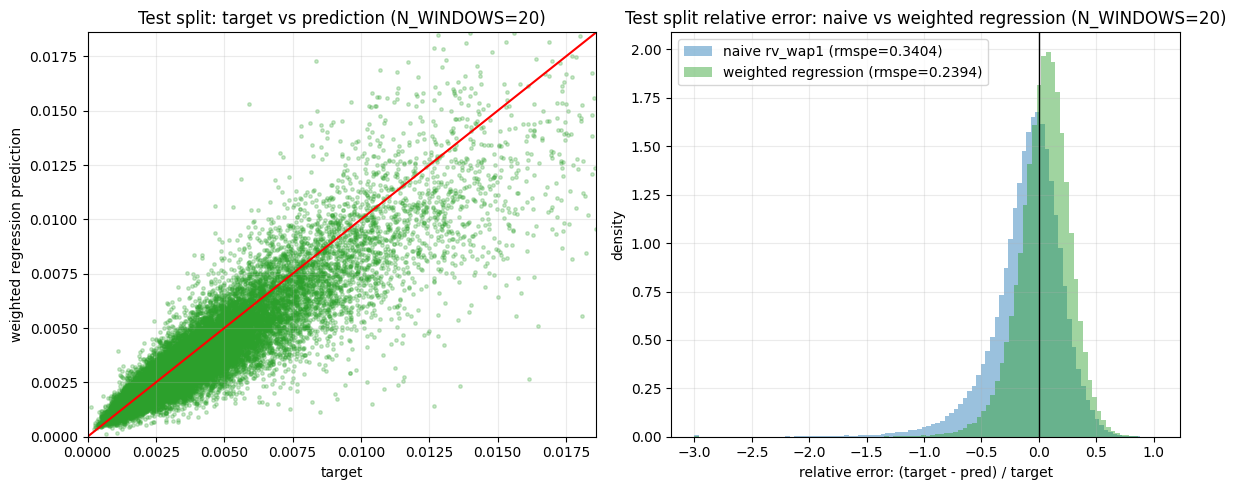

In [41]:

# Visualize weighted-regression results vs naive baseline (test split, all stocks)
test_compare = test_all.assign(pred_lr=test_all_pred).merge(
    test_eval[["stock_id", "time_id", "pred"]], on=["stock_id", "time_id"], how="inner"
)

rel_error_lr = (test_compare["target"] - test_compare["pred_lr"]) / test_compare["target"]
rel_error_naive = (test_compare["target"] - test_compare["pred"]) / test_compare["target"]

plot_sample = test_compare.sample(min(len(test_compare), 30000), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(plot_sample["target"], plot_sample["pred_lr"], s=6, alpha=0.25, color="tab:green")
limit = max(plot_sample["target"].quantile(0.995), plot_sample["pred_lr"].quantile(0.995))
axes[0].plot([0, limit], [0, limit], color="red", linewidth=1.5)
axes[0].set_xlim(0, limit)
axes[0].set_ylim(0, limit)
axes[0].set_xlabel("target")
axes[0].set_ylabel("weighted regression prediction")
axes[0].set_title(f"Test split: target vs prediction (N_WINDOWS={N_WINDOWS})")
axes[0].grid(True, alpha=0.25)

axes[1].hist(rel_error_naive.clip(-3, 3), bins=100, density=True, alpha=0.45, color="tab:blue",
             label=f"naive rv_wap1 (rmspe={rmspe(test_compare['target'], test_compare['pred']):.4f})")
axes[1].hist(rel_error_lr.clip(-3, 3), bins=100, density=True, alpha=0.45, color="tab:green",
             label=f"weighted regression (rmspe={rmspe(test_compare['target'], test_compare['pred_lr']):.4f})")
axes[1].axvline(0, color="black", linewidth=1.0)
axes[1].set_xlabel("relative error: (target - pred) / target")
axes[1].set_ylabel("density")
axes[1].set_title(f"Test split relative error: naive vs weighted regression (N_WINDOWS={N_WINDOWS})")
axes[1].legend()
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


In [42]:
# All-stocks, N-window gradient boosting (HistGradientBoostingRegressor): target ~ engineered features, weighted by 1/target^2
from sklearn.ensemble import HistGradientBoostingRegressor

hgb = HistGradientBoostingRegressor(
    max_iter=3000,
    early_stopping=True,
    n_iter_no_change=30,
    validation_fraction=0.1,
    l2_regularization=1.0,
    random_state=42,
)
hgb.fit(train_all[feature_cols], train_all["target"], sample_weight=1.0 / train_all["target"] ** 2)

train_hgb_pred = hgb.predict(train_all[feature_cols])
test_hgb_pred = hgb.predict(test_all[feature_cols])

# match the naive baseline to the exact same rows used to evaluate the models (some rows are dropped by dropna(feature_cols))
naive_matched = test_eval.merge(test_all[["stock_id", "time_id"]], on=["stock_id", "time_id"], how="inner")

print(f"N_WINDOWS = {N_WINDOWS} | all stocks | train rows: {len(train_all):,} | test rows: {len(test_all):,}\n")
print(f"HistGradientBoostingRegressor (max_iter=3000, early_stopping=True, n_iter_no_change=30, l2_regularization=1.0) "
      f"stopped after {hgb.n_iter_} iterations")
print("on engineered features (weighted by 1/target^2):")
print(f"  train  r2={r2_score(train_all['target'], train_hgb_pred):.4f}  rmspe={rmspe(train_all['target'], train_hgb_pred):.4f}")
print(f"  test   r2={r2_score(test_all['target'], test_hgb_pred):.4f}  rmspe={rmspe(test_all['target'], test_hgb_pred):.4f}")
print(f"\ncomparison on matched test rows ({len(naive_matched):,} rows):")
print(f"  naive rv_wap1 baseline : rmspe={rmspe(naive_matched['target'], naive_matched['pred']):.4f}")
print(f"  linear regression      : rmspe={rmspe(test_all['target'], test_all_pred):.4f}")
print(f"  gradient boosting      : rmspe={rmspe(test_all['target'], test_hgb_pred):.4f}")


N_WINDOWS = 20 | all stocks | train rows: 204,491 | test rows: 204,250

HistGradientBoostingRegressor (max_iter=3000, early_stopping=True, n_iter_no_change=30, l2_regularization=1.0) stopped after 42 iterations
on engineered features (weighted by 1/target^2):
  train  r2=0.7823  rmspe=0.2202
  test   r2=0.7741  rmspe=0.2373

comparison on matched test rows (204,250 rows):
  naive rv_wap1 baseline : rmspe=0.3404
  linear regression      : rmspe=0.2394
  gradient boosting      : rmspe=0.2373


In [ ]:
# All-stocks, N-window LightGBM: target ~ engineered features, weighted by 1/target^2
import lightgbm as lgb

# carve an early-stopping validation set out of train_time_ids (last 10% chronologically), keeping test_all fully held out
es_split_idx = int(len(train_time_ids) * 0.9)
fit_time_ids = train_time_ids[:es_split_idx]
es_time_ids = train_time_ids[es_split_idx:]

fit_mask = train_all["time_id"].isin(fit_time_ids)
es_mask = train_all["time_id"].isin(es_time_ids)

X_fit, y_fit = train_all.loc[fit_mask, feature_cols], train_all.loc[fit_mask, "target"]
X_es, y_es = train_all.loc[es_mask, feature_cols], train_all.loc[es_mask, "target"]

lgbm = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    reg_lambda=1.0,
    random_state=42,
    verbosity=-1,
)

lgbm.fit(
    X_fit, y_fit,
    sample_weight=1.0 / y_fit ** 2,
    eval_set=[(X_es, y_es)],
    eval_sample_weight=[1.0 / y_es ** 2],
    eval_metric="l2",
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)],
)

train_lgb_pred = lgbm.predict(train_all[feature_cols])
test_lgb_pred = lgbm.predict(test_all[feature_cols])

print(f"N_WINDOWS = {N_WINDOWS} | fit rows: {len(X_fit):,} | early-stop val rows: {len(X_es):,} | test rows: {len(test_all):,}")
print(f"LightGBM stopped at iteration {lgbm.best_iteration_}\n")
print(f"  train  r2={r2_score(train_all['target'], train_lgb_pred):.4f}  rmspe={rmspe(train_all['target'], train_lgb_pred):.4f}")
print(f"  test   r2={r2_score(test_all['target'], test_lgb_pred):.4f}  rmspe={rmspe(test_all['target'], test_lgb_pred):.4f}")
print(f"\ncomparison on matched test rows ({len(naive_matched):,} rows):")
print(f"  naive rv_wap1 baseline     : rmspe={rmspe(naive_matched['target'], naive_matched['pred']):.4f}")
print(f"  linear regression          : rmspe={rmspe(test_all['target'], test_all_pred):.4f}")
print(f"  gradient boosting (sklearn): rmspe={rmspe(test_all['target'], test_hgb_pred):.4f}")
print(f"  lightgbm                   : rmspe={rmspe(test_all['target'], test_lgb_pred):.4f}")


N_WINDOWS = 20 | fit rows: 183,981 | early-stop val rows: 20,510 | test rows: 204,250
LightGBM stopped at iteration 136

  train  r2=0.8121  rmspe=0.2082
  test   r2=0.7934  rmspe=0.2341

comparison on matched test rows (204,250 rows):
  naive rv_wap1 baseline     : rmspe=0.3404
  linear regression          : rmspe=0.2394
  gradient boosting (sklearn): rmspe=0.2373
  lightgbm                   : rmspe=0.2341


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score

def rmspe(y_true, y_pred):
    p_error = ((y_true - y_pred) / y_true)**2
    return np.sqrt(np.mean(p_error))

def RV(r): 
    return np.sqrt(np.sum((r) **2))

def return_calc(prices):
    return np.log(prices).diff()


def baseline_pred(stock_id, time_inds):

    book = pd.read_parquet(data_dir/"book_train.parquet"/f"stock_id={stock_id}")
    book = book[book["time_id"].isin(time_inds)].copy()
    book["wap_1"] = (book["bid_price1"] * book["ask_size1"] + book["ask_price1"] * book["bid_size1"])/(book["bid_size1"]+book["ask_size1"])
    book["return_1"] = book.groupby("time_id")["wap_1"].transform(return_calc)
    book_clean = book.dropna(subset = ["return_1"])


    realized_vol = book_clean.groupby("time_id")["return_1"].agg(RV)


    base_line_pred = pd.DataFrame({"time_id" : realized_vol.index, "current_vl": realized_vol.values})
    base_line_pred = base_line_pred.merge(train[train["stock_id"] == stock_id][["stock_id","time_id", "target"]], on="time_id")

    return base_line_pred


def bootstrap(prediction_data, column_target, column_pred):
    rng = np.random.default_rng(0)
    rmspe_list = []
    n = prediction_data.shape[0]
    for _ in range(100):
        idx = rng.choice(n, n, replace=True)
        sample = prediction_data.iloc[idx]
        rmspe_list.append(rmspe(sample[column_target],sample[column_pred]))
    return rmspe_list


data_dir = Path("../../data/optiver_volatility")
train = pd.read_csv(data_dir/"train.csv")

stock_list = train["stock_id"].unique()
time_id_list = train["time_id"].unique()
time_id_train = time_id_list[:len(time_id_list)//2]
time_id_test = time_id_list[len(time_id_list)//2:]

In [2]:
base_line_prediction = pd.concat(
    [baseline_pred(s, time_id_test) for s in stock_list],
    axis=0, ignore_index=True)

rmspe_list_base_line = bootstrap(base_line_prediction, "target", "current_vl")

print(np.mean(rmspe_list_base_line), np.std(rmspe_list_base_line))



0.343725530950704 0.005097315425403766


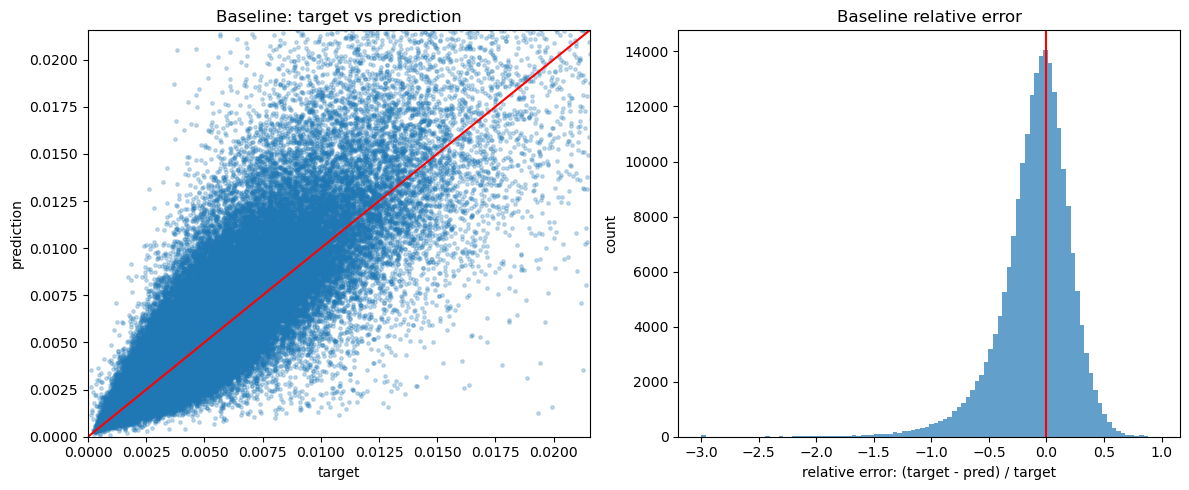

In [3]:
pred = base_line_prediction
rel_error = (pred["target"] - pred["current_vl"]) / pred["target"]
limit = max(pred["target"].quantile(0.995), pred["current_vl"].quantile(0.995))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(pred["target"], pred["current_vl"], s=6, alpha=0.25)
axes[0].plot([0, limit], [0, limit], color="red", linewidth=1.5)
axes[0].set_xlim(0, limit); axes[0].set_ylim(0, limit)
axes[0].set_xlabel("target"); axes[0].set_ylabel("prediction")
axes[0].set_title("Baseline: target vs prediction")

axes[1].hist(rel_error.clip(-3, 3), bins=100, alpha=0.7)
axes[1].axvline(0, color="red", linewidth=1.5)
axes[1].set_xlabel("relative error: (target - pred) / target")
axes[1].set_ylabel("count")
axes[1].set_title("Baseline relative error")

plt.tight_layout()
plt.show()

In [7]:
def features_single_stock(stock_id):
    book = pd.read_parquet(data_dir/"book_train.parquet"/f"stock_id={stock_id}")

    book["wap1"] = (book["bid_price1"]*book["ask_size1"] +  book["ask_price1"]*book["bid_size1"]) /(book["ask_size1"]+ book["bid_size1"])
    book["return1"] = book.groupby("time_id")["wap1"].transform(return_calc)
    book["spread"] = (book["ask_price1"] - book["bid_price1"]) / book["wap1"]
    book["imbalance"] = (book["bid_size1"] - book["ask_size1"])/(book["bid_size1"] + book["ask_size1"])
    book["wap2"] = (book["bid_price2"]*book["ask_size2"] +  book["ask_price2"]*book["bid_size2"]) /(book["ask_size2"]+ book["bid_size2"])
    book["return2"] = book.groupby("time_id")["wap2"].transform(return_calc)
    book = book.dropna(subset="return1")
    
    out = book.groupby("time_id").agg( rv1 = ("return1",RV ), rv2 = ("return2",RV ), mean_sp = ("spread", "mean"), std_sp=("spread", "std") ).reset_index()
    out["stock_id"] = stock_id
    return out 
features_all_stock = pd.concat([features_single_stock(s) for s in stock_list], axis=0, ignore_index=True)
features_all_stock = features_all_stock.merge(train[["stock_id", "target",  "time_id"]], on= ["stock_id", "time_id"])

In [9]:
feature_list = [ 'rv1', 'rv2', 'mean_sp', 'std_sp']


feature_train = features_all_stock[features_all_stock["time_id"].isin(time_id_train)]
feature_test = features_all_stock[features_all_stock["time_id"].isin(time_id_test)]

print(feature_train.mean(axis= 0))


time_id     7977.461707
rv1            0.004233
rv2            0.005813
mean_sp        0.000661
std_sp         0.000220
stock_id      62.437353
target         0.003891
dtype: float64


In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold

def cv_train_model(feature_train, model):

    rmspe_list = []

    n = feature_train.shape[0]
    split = KFold(n_splits=5, shuffle=False)

    for train_ , val_ in split.split(time_id_train):
        train_ = time_id_train[train_]
        val_ = time_id_train[val_]
        model.fit(feature_train[feature_train["time_id"].isin(train_)][feature_list].div(feature_train[feature_train["time_id"].isin(train_)]["target"], axis = 0), np.ones(feature_train[feature_train["time_id"].isin(train_)].shape[0])) 
        y_pred_mode1 = model.predict(feature_train[feature_train["time_id"].isin(val_)][feature_list])
        rmspe_list.append(rmspe(feature_train[feature_train["time_id"].isin(val_)]["target"],y_pred_mode1))

    return np.mean(rmspe_list), np.std(rmspe_list, ddof=1)
        

model1 = LinearRegression(fit_intercept=False)
print("train error mean and std :", cv_train_model(feature_train, model1))
model1.fit(feature_train[feature_list].div(feature_train["target"], axis = 0), np.ones(len(feature_train)))
y_pred_mode1_test = model1.predict(feature_test[feature_list])
data_model1 = pd.DataFrame({"pred": y_pred_mode1_test, "target": feature_test["target"]} )
test_Results = bootstrap(data_model1, "target", "pred")


print("test error mean and std :",np.mean(test_Results), np.std(test_Results, ddof=1))

train error mean and std : (np.float64(0.27907936494669544), np.float64(0.007174146579304539))
test error mean and std : 0.28061150635868587 0.003913487431285945


In [20]:
def features_single_stock(stock_id, n_sub):

    window_length = 600/n_sub
    book = pd.read_parquet(data_dir/"book_train.parquet"/f"stock_id={stock_id}")

    book["wap1"] = (book["bid_price1"]*book["ask_size1"] +  book["ask_price1"]*book["bid_size1"]) /(book["ask_size1"]+ book["bid_size1"])
    book["return1"] = book.groupby("time_id")["wap1"].transform(return_calc)
    book["spread"] = (book["ask_price1"] - book["bid_price1"]) / book["wap1"]
    book["imbalance"] = (book["bid_size1"] - book["ask_size1"])/(book["bid_size1"] + book["ask_size1"])
    book["wap2"] = (book["bid_price2"]*book["ask_size2"] +  book["ask_price2"]*book["bid_size2"]) /(book["ask_size2"]+ book["bid_size2"])
    book["return2"] = book.groupby("time_id")["wap2"].transform(return_calc)
    book["sub_window"] = book["seconds_in_bucket"]//window_length
    book = book.dropna(subset=["return1", "return2"])
    
    out = book.groupby(["time_id", "sub_window"]).agg( rv1 = ("return1",RV ), rv2 = ("return2",RV ), mean_sp = ("spread", "mean"), std_sp=("spread", "std") ).reset_index()


    g = out.pivot (index = "time_id", columns= "sub_window", values = ["rv1", "rv2" , "mean_sp" ,"std_sp"])
    g.columns = [ f"{c}_{int(w)}" for c, w in g.columns ]
    g["stock_id"] = stock_id
    g = g.reset_index()
    return g 


features_single_stock(0, 10)

,time_id,rv1_0,rv1_1,rv1_2,rv1_3,rv1_4,rv1_5,rv1_6,rv1_7,rv1_8,...,std_sp_1,std_sp_2,std_sp_3,std_sp_4,std_sp_5,std_sp_6,std_sp_7,std_sp_8,std_sp_9,stock_id
0,5,0.001649,0.001151,0.001994,0.001525,0.001083,0.001637,0.001639,0.001098,0.000774,...,0.000023,0.000102,0.000178,2.184557e-04,0.000164,0.000265,0.000171,0.000112,2.055323e-04,0
1,11,0.000304,0.000418,0.000309,0.000281,0.000218,0.000114,0.000307,0.000228,0.000442,...,0.000134,0.000167,0.000070,9.598423e-05,0.000034,0.000069,0.000053,0.000066,2.045900e-04,0
2,16,0.000832,0.000235,0.001043,0.000568,0.001333,0.000444,0.000374,0.000860,0.000704,...,0.000071,0.000064,0.000108,2.087892e-04,0.000120,0.000124,0.000046,0.000047,1.333210e-04,0
3,31,0.000150,0.000964,0.001046,0.001089,0.000489,0.000031,0.001468,0.000154,0.000326,...,0.000116,0.000251,0.000040,1.329056e-04,0.000047,0.000321,0.000024,0.000046,9.102031e-05,0
4,62,0.000393,0.000905,0.000290,0.000298,0.000364,0.000342,0.000383,0.000846,0.000511,...,0.000100,0.000059,0.000097,1.384542e-04,0.000069,0.000112,0.000169,0.000102,6.380259e-05,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3825,32751,0.000871,0.000428,0.000205,0.001565,0.000650,0.000613,0.000817,0.000819,0.000664,...,0.000112,0.000105,0.000217,2.027832e-04,0.000101,0.000141,0.000092,0.000094,8.385363e-05,0
3826,32753,0.001105,0.000304,0.001143,0.000120,0.000146,0.000569,0.000744,0.001023,0.000261,...,0.000047,0.000137,0.000142,5.173880e-05,0.000081,0.000195,0.000109,0.000026,4.206702e-08,0
3827,32758,0.001144,0.001064,0.000770,0.001267,0.000362,0.001105,0.000511,0.000944,0.000946,...,0.000325,0.000142,0.000254,9.362438e-05,0.000167,0.000073,0.000255,0.000123,1.153319e-04,0
3828,32763,0.001001,0.000988,0.000763,0.000827,0.001210,0.001110,0.001089,0.000588,0.000680,...,0.000095,0.000131,0.000152,1.679641e-04,0.000109,0.000143,0.000116,0.000114,1.287578e-04,0
